<a href="https://colab.research.google.com/github/qamaranalytics/Python-projects/blob/main/Machine_Learning_codes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Download the Apple stock dataset here
url = "https://drive.google.com/file/d/1CwJNy5pBb9WkZfzSETxFsA5UtOZ9Hzbi/view?usp=share_link"

## **Preprocessing**

In [ ]:
!pip install plotly

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# Import libraries

import os
import pandas as pd
import numpy as np
from numpy import array
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import datetime as dt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [ ]:
import math
import seaborn as sns
import datetime as dt
from datetime import datetime
from itertools import cycle
sns.set_style("whitegrid")
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model
%matplotlib inline
plt.style.use("ggplot")

from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Reshape, Flatten, TimeDistributed, Conv1D, MaxPooling1D, Bidirectional, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance, accuracy_score

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/AAPL (1).csv")

In [ ]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2003-04-04,0.259286,0.261964,0.256964,0.257321,0.219011,146020000
1,2003-04-07,0.265179,0.266964,0.257321,0.258750,0.220227,196862400
2,2003-04-08,0.259107,0.261607,0.256429,0.258036,0.219619,128934400
3,2003-04-09,0.259286,0.261071,0.252500,0.253393,0.215667,146725600
4,2003-04-10,0.253571,0.256964,0.253571,0.256607,0.218403,107100000


In [ ]:
data.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
5029,2023-03-28,157.970001,158.490005,155.979996,157.649994,157.649994,45992200
5030,2023-03-29,159.369995,161.050003,159.350006,160.770004,160.770004,51305700
5031,2023-03-30,161.529999,162.470001,161.270004,162.360001,162.360001,49501700
5032,2023-03-31,162.440002,165.000000,161.910004,164.899994,164.899994,68694700
5033,2023-04-03,164.270004,166.289993,164.220001,166.169998,166.169998,56933100


In [ ]:
# Change the cases for the column names for simplicity in proceeding with the code
data.columns = ['date', 'open', 'high', 'low', 'close', 'adjclose', 'volume']

In [ ]:
data.head()

,date,open,high,low,close,adjclose,volume
0,2003-04-04,0.259286,0.261964,0.256964,0.257321,0.219011,146020000
1,2003-04-07,0.265179,0.266964,0.257321,0.258750,0.220227,196862400
2,2003-04-08,0.259107,0.261607,0.256429,0.258036,0.219619,128934400
3,2003-04-09,0.259286,0.261071,0.252500,0.253393,0.215667,146725600
4,2003-04-10,0.253571,0.256964,0.253571,0.256607,0.218403,107100000


In [ ]:
data.describe()

,open,high,low,close,adjclose,volume
count,5034.000000,5034.000000,5034.000000,5034.000000,5034.000000,5.034000e+03
mean,36.185599,36.597889,35.785162,36.208358,34.805850,4.162790e+08
std,46.192491,46.771308,45.649860,46.236882,46.196370,3.935487e+08
min,0.231964,0.235536,0.227143,0.234286,0.199405,3.519590e+07
25%,4.573125,4.651160,4.469822,4.551875,3.874185,1.261293e+08
50%,18.965894,19.121607,18.779999,18.965536,16.600392,2.853582e+08
75%,43.009376,43.358125,42.600000,42.996251,41.097492,5.838686e+08
max,182.630005,182.940002,179.119995,182.009995,180.683868,3.372970e+09


In [ ]:
# Checking null value
data.isnull().sum()

date        0
open        0
high        0
low         0
close       0
adjclose    0
volume      0
dtype: int64

In [ ]:
# Checking Data type of each column
print("Date column data type: ", type(data['date'][0]))
print("Open column data type: ", type(data['open'][0]))
print("Close column data type: ", type(data['close'][0]))
print("High column data type: ", type(data['high'][0]))
print("Low column data type: ", type(data['low'][0]))

Date column data type:  <class 'str'>
Open column data type:  <class 'numpy.float64'>
Close column data type:  <class 'numpy.float64'>
High column data type:  <class 'numpy.float64'>
Low column data type:  <class 'numpy.float64'>


In [ ]:
data['date'] = pd.to_datetime(data.date)
data.head()

,date,open,high,low,close,adjclose,volume
0,2003-04-04,0.259286,0.261964,0.256964,0.257321,0.219011,146020000
1,2003-04-07,0.265179,0.266964,0.257321,0.258750,0.220227,196862400
2,2003-04-08,0.259107,0.261607,0.256429,0.258036,0.219619,128934400
3,2003-04-09,0.259286,0.261071,0.252500,0.253393,0.215667,146725600
4,2003-04-10,0.253571,0.256964,0.253571,0.256607,0.218403,107100000


In [ ]:
data.sort_values(by='date', inplace=True)
data.head()

,date,open,high,low,close,adjclose,volume
0,2003-04-04,0.259286,0.261964,0.256964,0.257321,0.219011,146020000
1,2003-04-07,0.265179,0.266964,0.257321,0.258750,0.220227,196862400
2,2003-04-08,0.259107,0.261607,0.256429,0.258036,0.219619,128934400
3,2003-04-09,0.259286,0.261071,0.252500,0.253393,0.215667,146725600
4,2003-04-10,0.253571,0.256964,0.253571,0.256607,0.218403,107100000


In [ ]:
data.shape

(5034, 7)

In [ ]:
print("Starting date: ",data.iloc[0][0])
print("Ending date: ", data.iloc[-1][0])
print("Duration: ", data.iloc[-1][0]-data.iloc[0][0])

Starting date:  2003-04-04 00:00:00
Ending date:  2023-04-03 00:00:00
Duration:  7304 days 00:00:00


In [ ]:
closedf = data[['date','close']]
dataf = data[data["date"] > "2022-04-04"]
df = closedf[closedf['date'] > '2022-04-04']
df_stock = df.copy()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
closedf["close"]

0         0.257321
1         0.258750
2         0.258036
3         0.253393
4         0.256607
           ...    
5029    157.649994
5030    160.770004
5031    162.360001
5032    164.899994
5033    166.169998
Name: close, Length: 5034, dtype: float64

In [ ]:
from statsmodels.tsa.stattools import adfuller

<ipython-input-20-6cf617ef5a3c>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns_plot = sns.distplot(df_stock['close'])


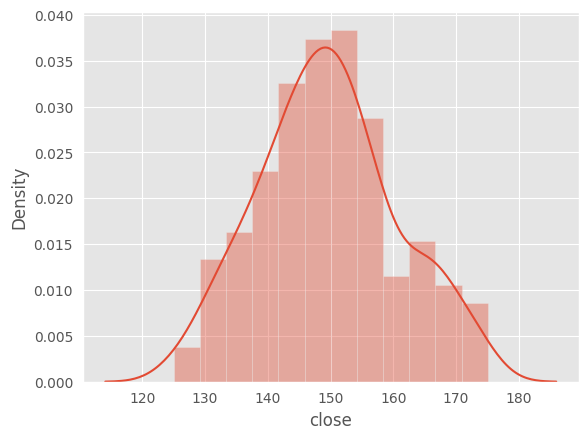

In [ ]:
sns_plot = sns.distplot(df_stock['close'])
#sns_plot2 = sns.distplot(dataY['close'])

In [ ]:
df_stock

,date,close
4784,2022-04-05,175.059998
4785,2022-04-06,171.830002
4786,2022-04-07,172.139999
4787,2022-04-08,170.089996
4788,2022-04-11,165.750000
...,...,...
5029,2023-03-28,157.649994
5030,2023-03-29,160.770004
5031,2023-03-30,162.360001
5032,2023-03-31,164.899994


<ipython-input-22-5ed7236e4815>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataf['close'], ax = ax[0,1])
<ipython-input-22-5ed7236e4815>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataf['open'], ax = ax[1,1])
<ipython-input-22-5ed7236e4815>:8: UserWarning: 

`distplot` is a deprecate

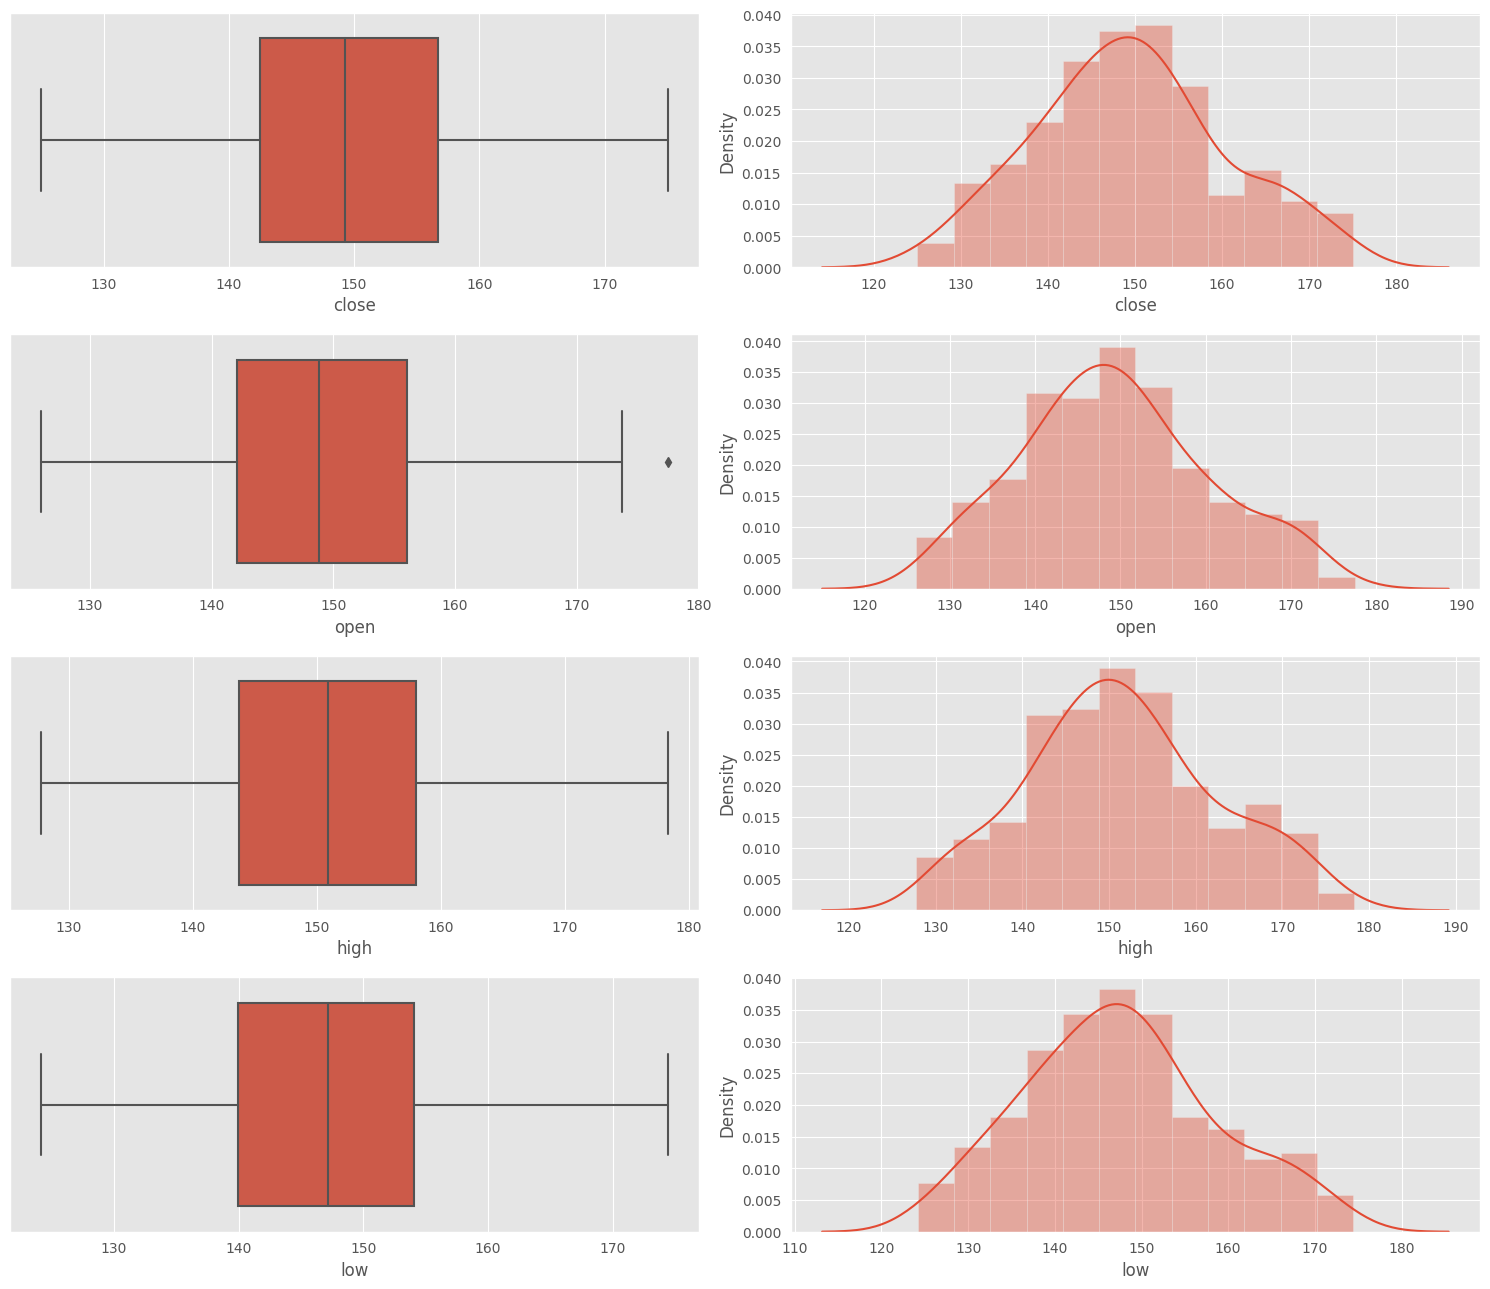

In [ ]:
# Plot to visualize the density and spread of our dataset
fig, ax = plt.subplots(4, 2, figsize = (15, 13))
sns.boxplot(x= dataf["close"], ax = ax[0,0])
sns.distplot(dataf['close'], ax = ax[0,1])
sns.boxplot(x= dataf["open"], ax = ax[1,0])
sns.distplot(dataf['open'], ax = ax[1,1])
sns.boxplot(x= dataf["high"], ax = ax[2,0])
sns.distplot(dataf['high'], ax = ax[2,1])
sns.boxplot(x= dataf["low"], ax = ax[3,0])
sns.distplot(dataf['low'], ax = ax[3,1])
plt.tight_layout()

<ipython-input-23-79df25da6462>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(dataf.corr(),cmap=plt.cm.Reds,annot=True)


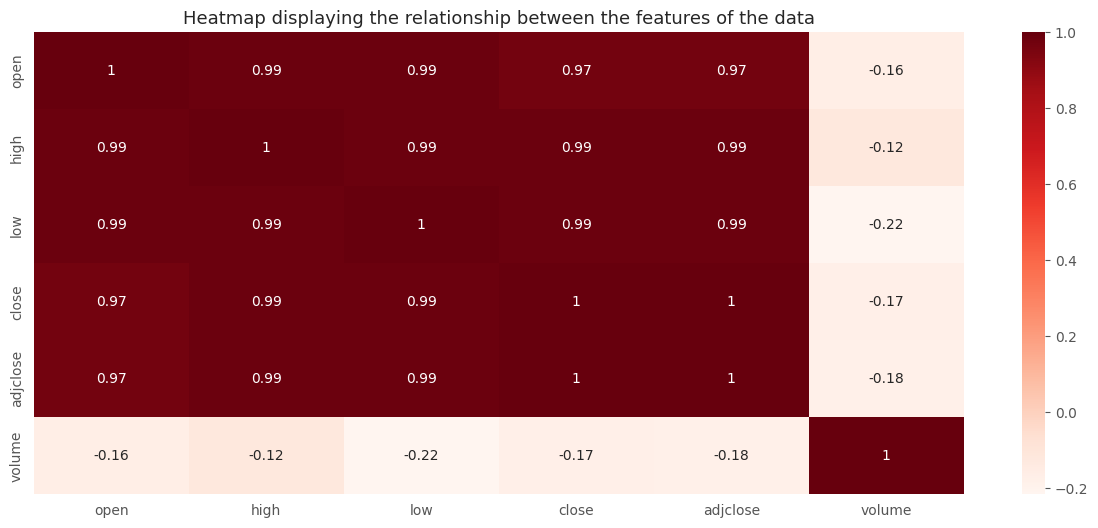

In [ ]:
plt.figure(figsize=(15,6))
sns.heatmap(dataf.corr(),cmap=plt.cm.Reds,annot=True)
plt.title('Heatmap displaying the relationship between the features of the data',
         fontsize=13)
plt.show()

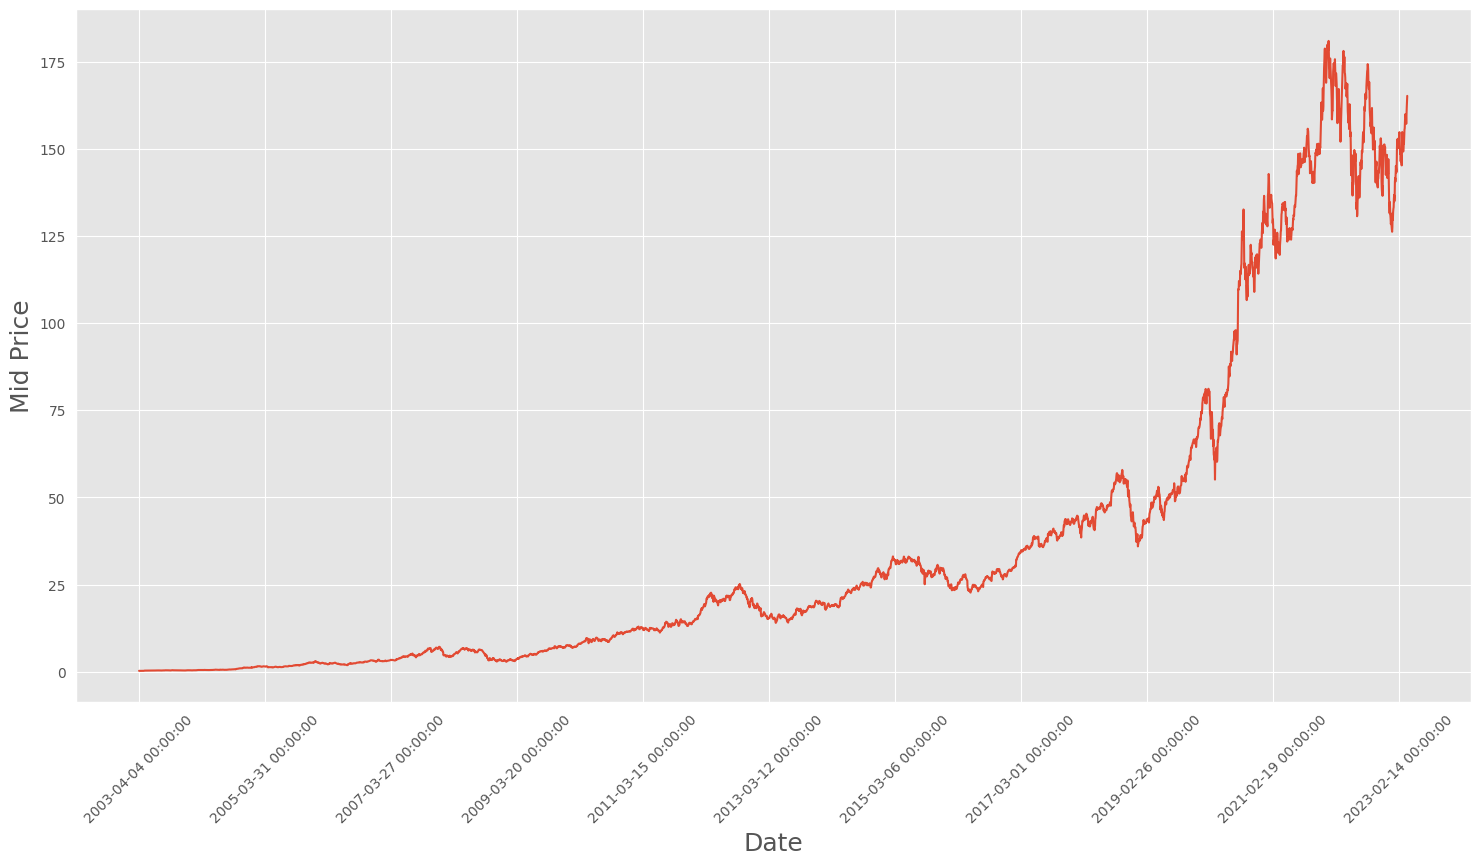

In [ ]:
plt.figure(figsize = (18,9))
plt.plot(range(data.shape[0]),(data['low']+data['high'])/2.0)
plt.xticks(range(0,data.shape[0],500),data['date'].loc[::500],rotation=45)
plt.xlabel('Date',fontsize=18)
plt.ylabel('Mid Price',fontsize=18)
plt.show()

In [ ]:
names = cycle(['Stock Open Price','Stock Close Price','Stock High Price','Stock Low Price'])

fig = px.line(dataf, dataf.date, y=[dataf['open'], dataf['close'],
                                          dataf['high'], dataf['low']],
             labels={'date': 'Date','value':'Stock value'})
fig.update_layout(title_text='Stock analysis chart', font_size=15, font_color='black',legend_title_text='Stock Parameters')
fig.for_each_trace(lambda t:  t.update(name = next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

Make Seperate dataset with closed price

In [ ]:
closedf = data[['date','close']]
print("Shape of close dataframe:", closedf.shape)

Shape of close dataframe: (5034, 2)


In [ ]:
closedf.head()

,date,close
0,2003-04-04,0.257321
1,2003-04-07,0.258750
2,2003-04-08,0.258036
3,2003-04-09,0.253393
4,2003-04-10,0.256607


In [ ]:
closedf.shape

(5034, 2)

In [ ]:
# Consider only the last One year data for prediction
df = closedf[closedf['date'] > '2022-04-04']
df_stock = df.copy()
print("Total data for prediction: ", df.shape[0])

Total data for prediction:  250


In [ ]:
# Remove the data column because it's not needed in our analysis and normalize the data frame
del df['date']
scaler=MinMaxScaler(feature_range=(0,1))
df=scaler.fit_transform(np.array(df).reshape(-1,1))
print(df.shape)

(250, 1)


In [ ]:
# Prepare the Data for train and test
train_len=int(len(df)*0.65)
test_size=len(df)-train_len
train_data,test_data=df[0:train_len,:],df[train_len:len(df),:1]
print("train_data: ", train_data.shape)
print("test_data: ", test_data.shape)

train_data:  (162, 1)
test_data:  (88, 1)


In [ ]:
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
    data_x, data_y = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]   ##
        data_x.append(a)
        data_y.append(dataset[i + time_step, 0])
    return np.array(data_x), np.array(data_y)

In [ ]:
time_step = 15
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [ ]:
print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test", y_test.shape)

X_train:  (146, 15)
y_train:  (146,)
X_test:  (72, 15)
y_test (72,)


In [ ]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)

X_train:  (146, 15, 1)
X_test:  (72, 15, 1)


In [ ]:
# reshape output to be [samples, features] which is required for LSTM
y_train =y_train.reshape(y_train.shape[0] , 1)
y_test = y_test.reshape(y_test.shape[0], 1)

print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

y_train:  (146, 1)
y_test:  (72, 1)


## **ARIMA**

In [ ]:
!pip install pmdarima

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 51.1 MB/s eta 0:00:00


In [ ]:
from statsmodels.tsa.arima_model import ARIMA
#from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Axes: ylabel='Density'>

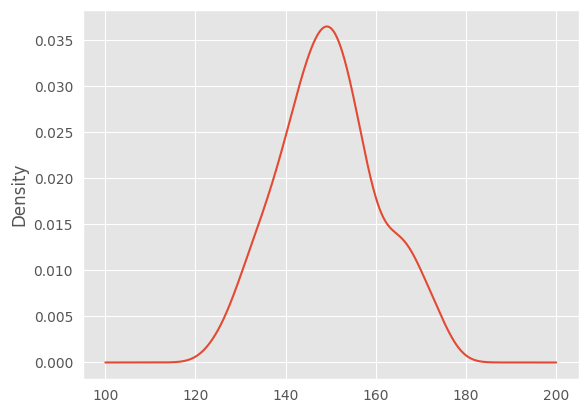

In [ ]:
#Distribution of the dataset

df_stock["close"].plot(kind='kde')

In [ ]:
closedf.set_index("date", inplace = True)
closedf

,close
date,
2003-04-04,0.257321
2003-04-07,0.258750
2003-04-08,0.258036
2003-04-09,0.253393
2003-04-10,0.256607
...,...
2023-03-28,157.649994
2023-03-29,160.770004
2023-03-30,162.360001


In [ ]:
data.head()

,date,open,high,low,close,adjclose,volume
0,2003-04-04,0.259286,0.261964,0.256964,0.257321,0.219011,146020000
1,2003-04-07,0.265179,0.266964,0.257321,0.258750,0.220227,196862400
2,2003-04-08,0.259107,0.261607,0.256429,0.258036,0.219619,128934400
3,2003-04-09,0.259286,0.261071,0.252500,0.253393,0.215667,146725600
4,2003-04-10,0.253571,0.256964,0.253571,0.256607,0.218403,107100000


<function matplotlib.pyplot.show(close=None, block=None)>

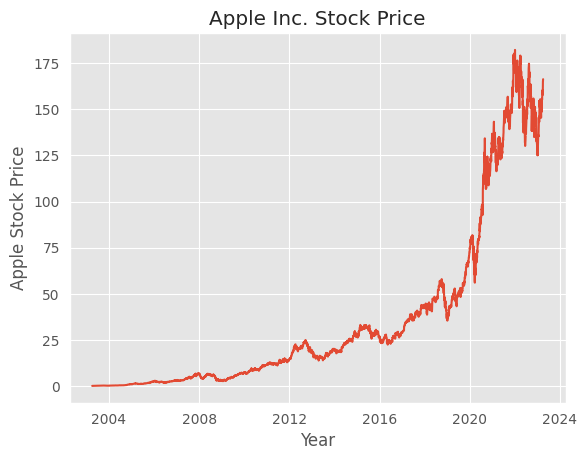

In [ ]:
# Plot the data
plt.plot(closedf)
plt.xlabel("Year")
plt.ylabel("Apple Stock Price")
plt.title("Apple Inc. Stock Price")
plt.show

In [ ]:
# Perform the differencing to remove the trend and seasonality
diff = closedf["close"].diff().dropna()

In [ ]:
diff

date
2003-04-07    0.001429
2003-04-08   -0.000714
2003-04-09   -0.004643
2003-04-10    0.003214
2003-04-11   -0.020893
                ...   
2023-03-28   -0.630005
2023-03-29    3.120010
2023-03-30    1.589997
2023-03-31    2.539993
2023-04-03    1.270004
Name: close, Length: 5033, dtype: float64

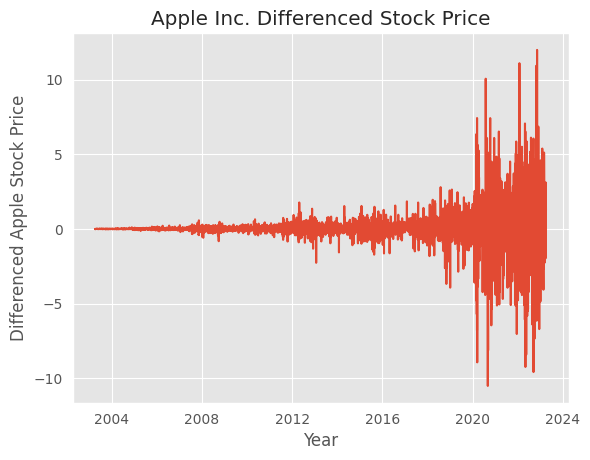

In [ ]:
# Plot the differenced data
plt.plot(diff)
plt.xlabel("Year")
plt.ylabel("Differenced Apple Stock Price")
plt.title("Apple Inc. Differenced Stock Price")
plt.show()

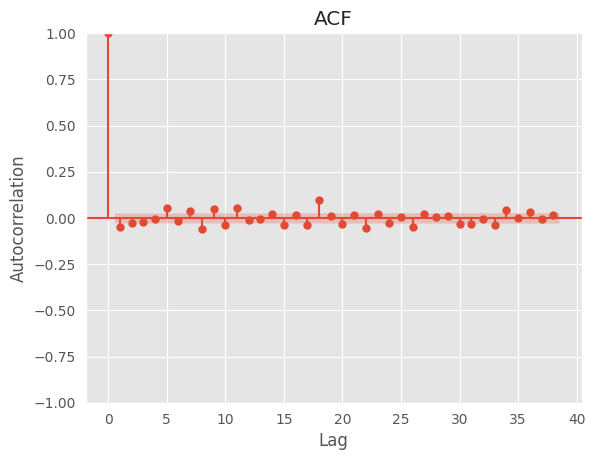

/usr/local/lib/python3.9/dist-packages/statsmodels/graphics/tsaplots.py:348: FutureWarning:

The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.



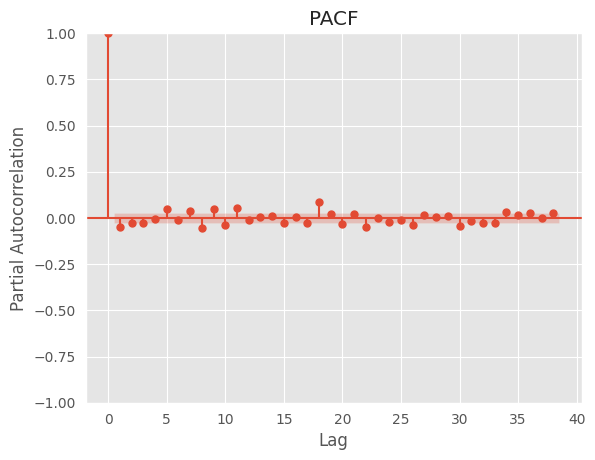

In [ ]:
# Plot the ACF and PACF to determine ARIMA model parameters
plot_acf(diff)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("ACF")
plt.show()

plot_pacf(diff)
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.title("PACF")
plt.show()

In [ ]:
# Split the data into training and test sets
train = closedf.iloc[:-30]
test = closedf.iloc[-30:]

In [ ]:
# Define the ARIMA model
model = sm.tsa.ARIMA(train["close"], order = (1, 1, 1))

/usr/local/lib/python3.9/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.9/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.9/dist-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



In [ ]:
# Fit the model
results = model.fit()

In [ ]:
forecast = results.forecast(steps = 30)

/usr/local/lib/python3.9/dist-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



In [ ]:
forecast.head()

5004    152.631832
5005    152.662221
5006    152.673507
5007    152.677699
5008    152.679255
Name: predicted_mean, dtype: float64

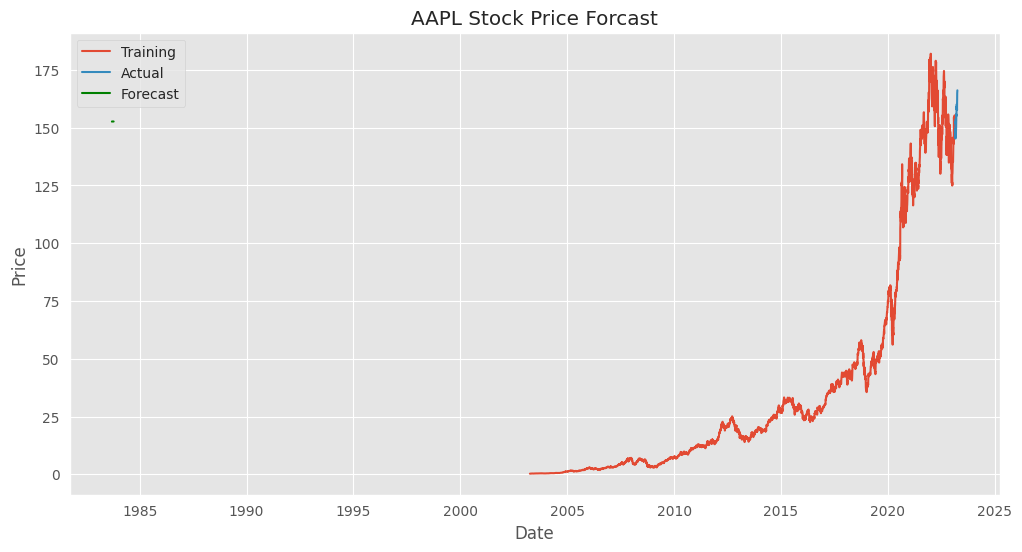

In [ ]:
#Plot the forecast

plt.figure(figsize = (12,6))
plt.plot(train["close"], label = "Training")
plt.plot(test["close"], label = "Actual")
plt.plot(forecast, color = "g", label = "Forecast")
plt.title("AAPL Stock Price Forcast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

### **Model Evaluation**

In [ ]:
mse = mean_squared_error(test["close"], forecast)
mse

33.69824585773349

In [ ]:
print("Test Data")
print("RMSE: ", math.sqrt(mean_squared_error(test["close"],forecast)))
print("MSE: ", mean_squared_error(test["close"],forecast))
print("MAE: ", mean_absolute_error(test["close"],forecast))

Test Data
RMSE:  5.805019023029424
MSE:  33.69824585773349
MAE:  4.803091476371119


In [ ]:
print("Test data explained variance score:", explained_variance_score(test["close"],forecast))

Test data explained variance score: 0.0008591663603366717


In [ ]:
# R-Squared score for regression

print("Test data R2 score:", r2_score(test["close"],forecast))

#  The ARIMA model does not follow the trend of the data and is predicting worse than the mean of the target values (ˉy)

Test data R2 score: -0.05150115388000809


In [ ]:
print("Test")
print("Data MPD: ", mean_poisson_deviance(test["close"],forecast))
print("Data MGD: ", mean_gamma_deviance(test["close"],forecast))

Test
Data MPD:  0.21806393215292133
Data MGD:  0.0014117242630484158


## **GRU**

### **The Process**

In [ ]:
# For creating model and training
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, LSTM, GRU, Dense, Dropout, Bidirectional, TimeDistributed, LeakyReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPooling1D, Flatten
from tensorflow.keras.regularizers import L1, L2
from tensorflow.keras.metrics import Accuracy
from tensorflow.keras.metrics import RootMeanSquaredError

In [ ]:
tf.keras.backend.clear_session()
model_gru=Sequential()
model_gru.add(GRU(32,return_sequences=True,input_shape=(time_step,1)))
model_gru.add(GRU(32,return_sequences=True))
model_gru.add(GRU(16))
model_gru.add(Dropout(0.20))
model_gru.add(Dense(1)) #add activation function
model_gru.compile(loss='mean_squared_error',optimizer='adam')

In [ ]:
from keras.models import Model
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping

In [ ]:
filepath = "model_gru"

In [ ]:
model_gru.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 15, 32)            3360      
                                                                 
 gru_1 (GRU)                 (None, 15, 32)            6336      
                                                                 
 gru_2 (GRU)                 (None, 16)                2400      
                                                                 
 dropout (Dropout)           (None, 16)                0         
                                                                 
 dense (Dense)               (None, 1)                 17        
                                                                 
Total params: 12,113
Trainable params: 12,113
Non-trainable params: 0
_________________________________________________________________


In [ ]:
history_gru = model_gru.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=200,batch_size=32, verbose=1)

Epoch 1/200
5/5 [==============================] - 6s 251ms/step - loss: 0.1685 - val_loss: 0.0389
Epoch 2/200
5/5 [==============================] - 0s 60ms/step - loss: 0.0366 - val_loss: 0.0183
Epoch 3/200
5/5 [==============================] - 0s 76ms/step - loss: 0.0401 - val_loss: 0.0225
Epoch 4/200
5/5 [==============================] - 0s 70ms/step - loss: 0.0360 - val_loss: 0.0125
Epoch 5/200
5/5 [==============================] - 0s 31ms/step - loss: 0.0229 - val_loss: 0.0157
Epoch 6/200
5/5 [==============================] - 0s 30ms/step - loss: 0.0252 - val_loss: 0.0146
Epoch 7/200
5/5 [==============================] - 0s 29ms/step - loss: 0.0292 - val_loss: 0.0110
Epoch 8/200
5/5 [==============================] - 0s 28ms/step - loss: 0.0210 - val_loss: 0.0107
Epoch 9/200
5/5 [==============================] - 0s 26ms/step - loss: 0.0191 - val_loss: 0.0100
Epoch 10/200
5/5 [==============================] - 0s 27ms/step - loss: 0.0165 - val_loss: 0.0102
Epoch 11/200
5/5 [

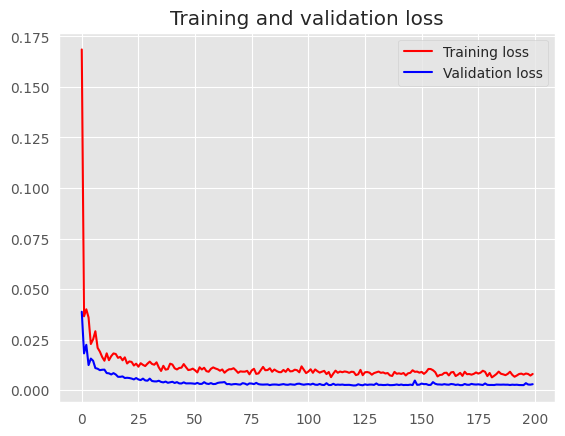

<Figure size 640x480 with 0 Axes>

In [ ]:
loss = history_gru.history['loss']
val_loss = history_gru.history['val_loss']

epochs = range(len(loss))

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend(loc=0)
plt.figure()


plt.show()

In [ ]:
### Make predictions
train_predict=model_gru.predict(X_train)
test_predict=model_gru.predict(X_test)
train_predict.shape, test_predict.shape

3/3 [==============================] - 0s 5ms/step


((146, 1), (72, 1))

In [ ]:
# and check performance metrics

In [ ]:
# Transform back to original form

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
original_ytrain = scaler.inverse_transform(y_train.reshape(-1,1))
original_ytest = scaler.inverse_transform(y_test.reshape(-1,1))

### **Model Evaluation**

In [ ]:
# Evaluation metrices RMSE and MAE
print("Train Data")
print("RMSE: ", math.sqrt(mean_squared_error(original_ytrain,train_predict)))
print("MSE: ", mean_squared_error(original_ytrain,train_predict))
print("MAE: ", mean_absolute_error(original_ytrain,train_predict))
print("-------------------------------------------------------------------------------------")
print("Test Data")
print("RMSE: ", math.sqrt(mean_squared_error(original_ytest,test_predict)))
print("MSE: ", mean_squared_error(original_ytest,test_predict))
print("MAE: ", mean_absolute_error(original_ytest,test_predict))

Train Data
RMSE:  3.650367481470442
MSE:  13.325182749776857
MAE:  2.8502989656263367
-------------------------------------------------------------------------------------
Test Data
RMSE:  2.759663112513556
MSE:  7.615740494568008
MAE:  2.199106691677516


In [ ]:
# The VAriance Regression Score
print("Train data explained variance score:", explained_variance_score(original_ytrain, train_predict))
print("Test data explained variance score:", explained_variance_score(original_ytest, test_predict))

Train data explained variance score: 0.8729653365051215
Test data explained variance score: 0.9335539054528537


In [ ]:
# R-Squared score for regression
print("Train data R2 score:", r2_score(original_ytrain, train_predict))
print("Test data R2 score:", r2_score(original_ytest, test_predict))

Train data R2 score: 0.8687868810675113
Test data R2 score: 0.9325586548449606


In [ ]:
# The mean gamma deviance and mean poisson deviance scores
print("Train")
print("Data MGD: ", mean_gamma_deviance(original_ytrain, train_predict))
print("Data MPD: ", mean_poisson_deviance(original_ytrain, train_predict))

print("----------------------------------------------------------------------")
print("Test")
print("Data MPD: ", mean_poisson_deviance(original_ytest, test_predict))
print("Data MGD: ", mean_gamma_deviance(original_ytest, test_predict))

Train
Data MGD:  0.0005960510654993252
Data MPD:  0.08895918811866213
----------------------------------------------------------------------
Test
Data MPD:  0.05320829917766506
Data MGD:  0.0003738786383651944


In [ ]:
# shift train predictions for plotting

look_back=time_step
trainPredictPlot = np.empty_like(df)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
print("Train predicted data: ", trainPredictPlot.shape)

# shift test predictions for plotting
testPredictPlot = np.empty_like(df)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df)-1, :] = test_predict
print("Test predicted data: ", testPredictPlot.shape)

names = cycle(['Original close price','Train predicted close price','Test predicted close price'])


plotdf = pd.DataFrame({'date': df_stock['date'],
                       'original_close': df_stock['close'],
                      'train_predicted_close': trainPredictPlot.reshape(1,-1)[0].tolist(),
                      'test_predicted_close': testPredictPlot.reshape(1,-1)[0].tolist()})

fig = px.line(plotdf, x=plotdf['date'], y=[plotdf['original_close'],plotdf['train_predicted_close'],
                                          plotdf['test_predicted_close']],
              labels={'value':'Stock price','date': 'Date'})
fig.update_layout(title_text='original close price vs predicted close price',
                  plot_bgcolor='white', font_size=15, font_color='black', legend_title_text='Close Price')
fig.for_each_trace(lambda t:  t.update(name = next(names)))

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

Train predicted data:  (250, 1)
Test predicted data:  (250, 1)


In [ ]:
x_input=test_data[len(test_data)-time_step:].reshape(1,-1)
temp_input=list(x_input)
temp_input=temp_input[0].tolist()

In [ ]:
temp_input

[2.517323704140039,
 2.525975860581321,
 2.5878374088820464,
 2.5694518603368164,
 2.6213635011902463,
 2.6620278296688396,
 2.6306645331345355,
 2.6544572333387877,
 2.68300885859619,
 2.640397925238483,
 2.626770977297835,
 2.694256495419593,
 2.7286479785741475,
 2.783587784417923,
 2.8110578495640937]

### **Predict the next 30 days**

In [ ]:
gru_output=[]
n_steps=time_step
i=0
pred_days = 30
while(i<pred_days):

    if(len(temp_input)>time_step):

        x_input=np.array(temp_input[1:]) # Convert to a numpy array
        #print("{} day input {}".format(i,x_input))
        x_input = x_input.reshape(1,-1) # Reshape to a 1 x 14 array
        x_input = x_input.reshape((1, n_steps, 1))

        yhat = model_gru.predict(x_input, verbose=0)
        #print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)

        gru_output.extend(yhat.tolist())
        i=i+1

    else:

        x_input = x_input.reshape((1, n_steps,1))
        yhat = model_gru.predict(x_input, verbose=0)
        temp_input.extend(yhat[0].tolist())

        gru_output.extend(yhat.tolist())
        i=i+1

print("Output of predicted next days: ", len(gru_output))

Output of predicted next days:  30


In [ ]:
gru_output

[[2.5343616008758545],
 [2.3265819549560547],
 [2.1778364181518555],
 [2.0551340579986572],
 [1.9491314888000488],
 [1.8543822765350342],
 [1.7673842906951904],
 [1.6857192516326904],
 [1.607647180557251],
 [1.5319745540618896],
 [1.4578523635864258],
 [1.3846139907836914],
 [1.3118326663970947],
 [1.2392899990081787],
 [1.1669678688049316],
 [1.095261573791504],
 [1.0248095989227295],
 [0.9563121199607849],
 [0.890520453453064],
 [0.8281950950622559],
 [0.7700338363647461],
 [0.7165996432304382],
 [0.6682664752006531],
 [0.6251939535140991],
 [0.5873342752456665],
 [0.5544630289077759],
 [0.5262247920036316],
 [0.5021824836730957],
 [0.48186132311820984],
 [0.4647842347621918]]

In [ ]:
# Plotting the next 30 days prediction

grudf=df.tolist() # Convert the datadrame to a list
grudf.extend((np.array(gru_output).reshape(-1,1)).tolist()) # Add the prediction for 30 days forward
grudf=scaler.inverse_transform(grudf).reshape(1,-1).tolist()[0] # Transform back to the real values before normalization

names = cycle(['Close price'])

fig = px.line(grudf,labels={'value': 'Stock price','index': 'Timestamp'})
fig.update_layout(title_text='Plotting whole closing stock price with prediction',
                  plot_bgcolor='white', font_size=15, font_color='black',legend_title_text='Stock')

fig.for_each_trace(lambda t:  t.update(name = next(names)))

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

## **LSTM**

### **The Process**

In [ ]:
# Build the Lstm model
tf.keras.backend.clear_session()
model_lstm=Sequential()
model_lstm.add(LSTM(64,return_sequences=True,input_shape=(time_step,1)))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(64,return_sequences=True))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(32))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1))
model_lstm.compile(loss='mean_squared_error',optimizer='adam')

In [ ]:
model_lstm.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 15, 64)            16896     
                                                                 
 dropout (Dropout)           (None, 15, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 15, 64)            33024     
                                                                 
 dropout_1 (Dropout)         (None, 15, 64)            0         
                                                                 
 lstm_2 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense (Dense)               (None, 1)                 3

In [ ]:
history_lstm = model_lstm.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=200,batch_size=32,verbose=1)

Epoch 1/200
5/5 [==============================] - 6s 261ms/step - loss: 0.1968 - val_loss: 0.0275
Epoch 2/200
5/5 [==============================] - 0s 29ms/step - loss: 0.0460 - val_loss: 0.0291
Epoch 3/200
5/5 [==============================] - 0s 30ms/step - loss: 0.0320 - val_loss: 0.0270
Epoch 4/200
5/5 [==============================] - 0s 33ms/step - loss: 0.0359 - val_loss: 0.0291
Epoch 5/200
5/5 [==============================] - 0s 32ms/step - loss: 0.0310 - val_loss: 0.0217
Epoch 6/200
5/5 [==============================] - 0s 30ms/step - loss: 0.0293 - val_loss: 0.0221
Epoch 7/200
5/5 [==============================] - 0s 29ms/step - loss: 0.0289 - val_loss: 0.0212
Epoch 8/200
5/5 [==============================] - 0s 29ms/step - loss: 0.0252 - val_loss: 0.0213
Epoch 9/200
5/5 [==============================] - 0s 28ms/step - loss: 0.0233 - val_loss: 0.0204
Epoch 10/200
5/5 [==============================] - 0s 30ms/step - loss: 0.0265 - val_loss: 0.0199
Epoch 11/200
5/5 [

In [ ]:
pd.DataFrame(history_lstm.history)

,loss,val_loss
0,0.196761,0.027517
1,0.045985,0.029127
2,0.031961,0.026974
3,0.035900,0.029121
4,0.030953,0.021718
...,...,...
195,0.008722,0.005169
196,0.011142,0.005120
197,0.009645,0.005185
198,0.010769,0.004857


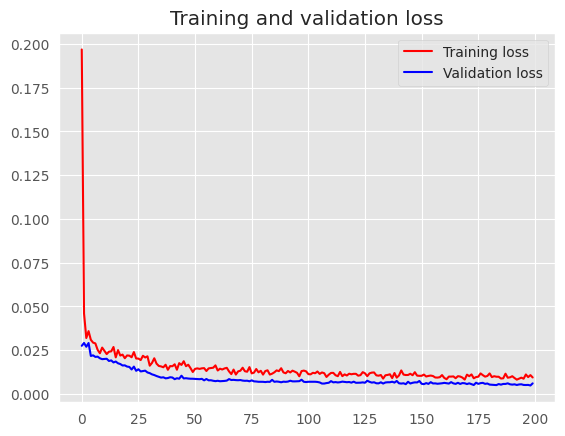

<Figure size 640x480 with 0 Axes>

In [ ]:
loss = history_lstm.history['loss']
val_loss = history_lstm.history['val_loss']

epochs = range(len(loss))

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend(loc=0)
plt.figure()


plt.show()

In [ ]:
### Prediction using lstm model
train_predict=model_lstm.predict(X_train)
test_predict=model_lstm.predict(X_test)
train_predict.shape, test_predict.shape

3/3 [==============================] - 0s 6ms/step


((146, 1), (72, 1))

In [ ]:
# Transform back to original form

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
original_ytrain = scaler.inverse_transform(y_train.reshape(-1,1))
original_ytest = scaler.inverse_transform(y_test.reshape(-1,1))

In [ ]:
# view the predicted values
test_predict

array([[141.73419],
       [139.15404],
       [136.5596 ],
       [134.73811],
       [134.38411],
       [134.37689],
       [134.3595 ],
       [133.99611],
       [132.86205],
       [132.16544],
       [132.0525 ],
       [131.50832],
       [130.93718],
       [130.34322],
       [130.57776],
       [131.42271],
       [132.45247],
       [133.75317],
       [134.88258],
       [135.81607],
       [136.64275],
       [137.053  ],
       [137.11253],
       [137.49742],
       [138.6708 ],
       [140.31226],
       [141.55545],
       [142.6158 ],
       [143.78534],
       [143.9511 ],
       [143.78635],
       [143.84572],
       [145.4051 ],
       [148.40794],
       [150.38028],
       [151.83643],
       [151.76544],
       [150.60887],
       [149.41202],
       [149.47525],
       [149.99673],
       [151.1448 ],
       [151.72389],
       [151.40416],
       [149.57059],
       [147.78758],
       [146.85187],
       [145.92912],
       [145.57416],
       [145.53001],


In [ ]:
test_predict.shape

(72, 1)

### **Model Evaluation**

In [ ]:
# Evaluation metrices RMSE and MAE
print("Train Data")
print("RMSE: ", math.sqrt(mean_squared_error(original_ytrain,train_predict)))
print("MSE: ", mean_squared_error(original_ytrain,train_predict))
print("MAE: ", mean_absolute_error(original_ytrain,train_predict))
print("-------------------------------------------------------------------------------------")
print("Test Data")
print("RMSE: ", math.sqrt(mean_squared_error(original_ytest,test_predict)))
print("MSE: ", mean_squared_error(original_ytest,test_predict))
print("MAE: ", mean_absolute_error(original_ytest,test_predict))

Train Data
RMSE:  4.403526716485342
MSE:  19.391047542800184
MAE:  3.5909768546861613
-------------------------------------------------------------------------------------
Test Data
RMSE:  3.8967760854134315
MSE:  15.184863859850026
MAE:  3.0957953822428386


In [ ]:
# The VAriance Regression Score
print("Train data explained variance score:", explained_variance_score(original_ytrain, train_predict))
print("Test data explained variance score:", explained_variance_score(original_ytest, test_predict))

Train data explained variance score: 0.8332330310605799
Test data explained variance score: 0.8759417910429738


In [ ]:
# R-Squared score for regression
print("Train data R2 score:", r2_score(original_ytrain, train_predict))
print("Test data R2 score:", r2_score(original_ytest, test_predict))

Train data R2 score: 0.8090562902410033
Test data R2 score: 0.8655301286283497


In [ ]:
# The mean gamma deviance and mean poisson deviance scores
print("Train")
print("Data MGD: ", mean_gamma_deviance(original_ytrain, train_predict))
print("Data MPD: ", mean_poisson_deviance(original_ytrain, train_predict))

print("----------------------------------------------------------------------")
print("Test")
print("Data MPD: ", mean_poisson_deviance(original_ytest, test_predict))
print("Data MGD: ", mean_gamma_deviance(original_ytest, test_predict))

Train
Data MGD:  0.0008711329500673624
Data MPD:  0.1297469579346806
----------------------------------------------------------------------
Test
Data MPD:  0.10485319696542206
Data MGD:  0.0007273828652263029


In [ ]:
# shift train predictions for plotting

look_back=time_step
trainPredictPlot = np.empty_like(df)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
print("Train predicted data: ", trainPredictPlot.shape)


Train predicted data:  (250, 1)


In [ ]:
# shift test predictions for plotting
testPredictPlot = np.empty_like(df)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df)-1, :] = test_predict
print("Test predicted data: ", testPredictPlot.shape)

Test predicted data:  (250, 1)


In [ ]:
# Create a dataframe of the date, close price, train predicted close price and the test predicted close price
plotdf = pd.DataFrame({'date': df_stock['date'],
                       'original_close': df_stock['close'],
                      'train_predicted_close': trainPredictPlot.reshape(1,-1)[0].tolist(),
                      'test_predicted_close': testPredictPlot.reshape(1,-1)[0].tolist()})

In [ ]:
plotdf

,date,original_close,train_predicted_close,test_predicted_close
4784,2022-04-05,175.059998,NaN,NaN
4785,2022-04-06,171.830002,NaN,NaN
4786,2022-04-07,172.139999,NaN,NaN
4787,2022-04-08,170.089996,NaN,NaN
4788,2022-04-11,165.750000,NaN,NaN
...,...,...,...,...
5029,2023-03-28,157.649994,NaN,156.308716
5030,2023-03-29,160.770004,NaN,155.500092
5031,2023-03-30,162.360001,NaN,155.835052
5032,2023-03-31,164.899994,NaN,157.234756


In [ ]:
names = cycle(['Original close price','Train predicted close price','Test predicted close price'])

# Make the plottings with date on the x axis and (original_close, train_predicted_close, test_predicted_close) on the y axis
fig = px.line(plotdf, x=plotdf['date'], y=[plotdf['original_close'],plotdf['train_predicted_close'],
                                          plotdf['test_predicted_close']],
              labels={'value':'Stock price','date': 'Date'})
fig.update_layout(title_text='original close price vs predicted close price',
                  plot_bgcolor='white', font_size=15, font_color='black', legend_title_text='Close Price')
fig.for_each_trace(lambda t:  t.update(name = next(names)))

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

### **Predict the next 30 days**

In [ ]:
#x_input=test_data[len(test_data)-time_step:].reshape(1,-1)
#temp_input=list(x_input)
#temp_input=temp_input[0].tolist()

In [ ]:

lstm_output=[]
n_steps=time_step
i=0
pred_days = 30
while(i<pred_days):

    if(len(temp_input)>time_step):

        x_input=np.array(temp_input[1:]) # Convert to a numpy array
        x_input = x_input.reshape(1,-1) # Reshape to a 1 x 14 array
        x_input = x_input.reshape((1, n_steps, 1))

        yhat = model_lstm.predict(x_input, verbose=0)
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]


        lstm_output.extend(yhat.tolist())
        i=i+1

    else:

        x_input = x_input.reshape((1, n_steps,1))
        yhat = model_lstm.predict(x_input, verbose=0)
        temp_input.extend(yhat[0].tolist())

        lstm_output.extend(yhat.tolist())
        i=i+1

print("Output of predicted next days: ", len(lstm_output))

Output of predicted next days:  30


In [ ]:

lstmdf=df.tolist() # Convert the dataframe to a list and assign it as lstmdf
lstmdf.extend((np.array(lstm_output).reshape(-1,1)).tolist()) # Add the prediction for 30 days forward
lstmdf=scaler.inverse_transform(lstmdf).reshape(1,-1).tolist()[0] # Transform back to the real values without normalization

names = cycle(['Close price'])

figure = px.line(lstmdf,labels={'value': 'Stock price','index': 'Timestamp'})
figure.update_layout(title_text='Plotting whole closing stock price with prediction',
                  plot_bgcolor='white', font_size=15, font_color='black',legend_title_text='Stock')

figure.for_each_trace(lambda t:  t.update(name = next(names)))

figure.update_xaxes(showgrid=False)
figure.update_yaxes(showgrid=False)
figure.show()

## **GAN**

In [ ]:
prices = data["close"].values
prices = prices.astype("float32")

In [ ]:
# Data normalization and preprocessing
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
prices = scaler.fit_transform(prices.reshape(-1, 1))

In [ ]:
# Data normalization and preprocessing
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
prices = scaler.fit_transform(prices.reshape(-1, 1))

def preprocess_data(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i: i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 60
X, y = preprocess_data(prices, window_size)

X_train, y_train = X[:-30], y[:-30]
X_test, y_test = X[-30:], y[-30:]

In [ ]:
y_train.shape

(4944, 1)

In [ ]:
# GAN architecture
def create_generator(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_dim=input_dim),
        Dense(512, activation='relu'),
        Dense(window_size, activation='linear'),
        Reshape((window_size, 1))
    ])
    return model

In [ ]:
def create_discriminator(input_shape):
    model = Sequential([
        LSTM(64, activation='relu', return_sequences=True, input_shape=input_shape),
        LSTM(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model


In [ ]:
def create_gan(generator, discriminator):
    model = Sequential([generator, discriminator])
    return model

In [ ]:
# Model creation
generator = create_generator(100)
discriminator = create_discriminator((window_size, 1))
discriminator.compile(loss='binary_crossentropy', optimizer=Adam(lr=0.0002, beta_1=0.5), metrics=['accuracy'])

discriminator.trainable = False
gan = create_gan(generator, discriminator)
gan.compile(loss='binary_crossentropy', optimizer=Adam(lr=0.0002, beta_1=0.5))

In [ ]:
### From here is corrections

In [ ]:
# Training the GAN
batch_size = 32
epochs = 100
noise_dim = 100

In [ ]:
for epoch in range(epochs):
    # Generate fake samples
    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    fake_samples = generator.predict(noise)

    # Select real samples
    real_samples = X_train[np.random.randint(0, X_train.shape[0], batch_size)]

    # Combine real and fake samples
    X_combined = np.concatenate((real_samples, fake_samples))
    y_combined = np.concatenate((np.ones((batch_size, 1)), np.zeros((batch_size, 1))))

    # Train the discriminator
    d_loss, d_acc = discriminator.train_on_batch(X_combined, y_combined)

    # Generate new random noise as input
    noise = np.random.normal(0, 1, size = (batch_size, noise_dim, 1))

    # Generate labels for the generator
    y_generator = np.ones(batch_size)


    # Train the generator
    g_loss = gan.train_on_batch(noise, y_generator)

    if epoch % 1000 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Discriminator Loss: {d_loss:.4f}, Generator Loss: {g_loss:.4f}')

1/1 [==============================] - 0s 55ms/step
Epoch 1/100, Discriminator Loss: 0.6930, Generator Loss: 0.6921
1/1 [==============================] - 0s 16ms/step


In [ ]:
d_acc

0.5

In [ ]:
d_loss

0.6949126720428467

In [ ]:
g_loss

0.7480173110961914

## **GRU - LSTM**

### **Process**

In [ ]:
print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)

X_train:  (146, 15, 1)
X_test:  (72, 15, 1)


In [ ]:
# Build the LSTM - GRU model
model_lstm_gru =Sequential()
model_lstm_gru.add(LSTM(64,return_sequences=True,input_shape=(time_step,1)))
model_lstm_gru.add(LSTM(64,return_sequences=True))
model_lstm_gru.add(GRU(32,return_sequences=True))
model_lstm_gru.add(GRU(32))
model_lstm_gru.add(Dense(1))
model_lstm_gru.compile(loss='mean_squared_error',optimizer='adam')

In [ ]:
model_lstm_gru.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 15, 64)            16896     
                                                                 
 lstm_4 (LSTM)               (None, 15, 64)            33024     
                                                                 
 gru (GRU)                   (None, 15, 32)            9408      
                                                                 
 gru_1 (GRU)                 (None, 32)                6336      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 65,697
Trainable params: 65,697
Non-trainable params: 0
_________________________________________________________________


In [ ]:
history_lstm_gru = model_lstm_gru.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=200,batch_size=32,verbose=1)

Epoch 1/200
5/5 [==============================] - 8s 514ms/step - loss: 0.1176 - val_loss: 0.0382
Epoch 2/200
5/5 [==============================] - 0s 51ms/step - loss: 0.0580 - val_loss: 0.0219
Epoch 3/200
5/5 [==============================] - 0s 46ms/step - loss: 0.0314 - val_loss: 0.0349
Epoch 4/200
5/5 [==============================] - 0s 61ms/step - loss: 0.0359 - val_loss: 0.0231
Epoch 5/200
5/5 [==============================] - 0s 46ms/step - loss: 0.0233 - val_loss: 0.0252
Epoch 6/200
5/5 [==============================] - 0s 57ms/step - loss: 0.0256 - val_loss: 0.0224
Epoch 7/200
5/5 [==============================] - 0s 47ms/step - loss: 0.0229 - val_loss: 0.0224
Epoch 8/200
5/5 [==============================] - 0s 47ms/step - loss: 0.0233 - val_loss: 0.0215
Epoch 9/200
5/5 [==============================] - 0s 61ms/step - loss: 0.0216 - val_loss: 0.0209
Epoch 10/200
5/5 [==============================] - 0s 55ms/step - loss: 0.0218 - val_loss: 0.0204
Epoch 11/200
5/5 [

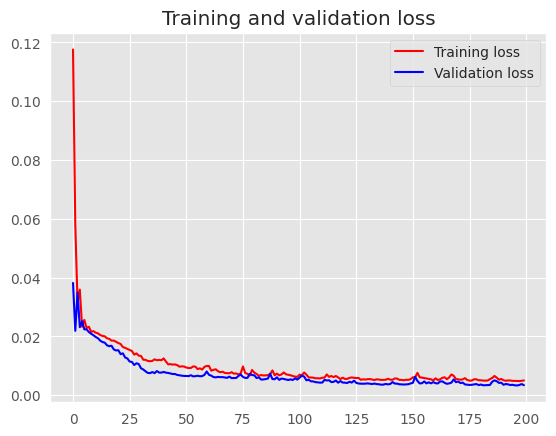

<Figure size 640x480 with 0 Axes>

In [ ]:
loss = history_lstm_gru.history['loss']
val_loss = history_lstm_gru.history['val_loss']

epochs = range(len(loss))

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend(loc=0)
plt.figure()


plt.show()

In [ ]:
### Prediction using lstm_gru model
train_predict=model_lstm_gru.predict(X_train)
test_predict=model_lstm_gru.predict(X_test)
train_predict.shape, test_predict.shape

3/3 [==============================] - 0s 9ms/step


((146, 1), (72, 1))

In [ ]:
# Transform back to original form

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
original_ytrain = scaler.inverse_transform(y_train.reshape(-1,1))
original_ytest = scaler.inverse_transform(y_test.reshape(-1,1))

### **Model Evaluation**

In [ ]:
# Evaluation metrices RMSE and MAE
print("Train Data")
print("RMSE: ", math.sqrt(mean_squared_error(original_ytrain,train_predict)))
print("MSE: ", mean_squared_error(original_ytrain,train_predict))
print("MAE: ", mean_absolute_error(original_ytrain,train_predict))
print("-------------------------------------------------------------------------------------")
print("Test Data")
print("RMSE: ", math.sqrt(mean_squared_error(original_ytest,test_predict)))
print("MSE: ", mean_squared_error(original_ytest,test_predict))
print("MAE: ", mean_absolute_error(original_ytest,test_predict))

Train Data
RMSE:  3.486020298278074
MSE:  12.152337520006752
MAE:  2.6643877602003943
-------------------------------------------------------------------------------------
Test Data
RMSE:  2.920566680204512
MSE:  8.529709733520804
MAE:  2.376194288085937


In [ ]:
# The Variance Regression Score
print("Train data explained variance score:", explained_variance_score(original_ytrain, train_predict))
print("Test data explained variance score:", explained_variance_score(original_ytest, test_predict))

Train data explained variance score: 0.8833942146793939
Test data explained variance score: 0.9244675904271977


In [ ]:
# R-Squared score for regression
print("Train data R2 score:", r2_score(original_ytrain, train_predict))
print("Test data R2 score:", r2_score(original_ytest, test_predict))

Train data R2 score: 0.8803358919526194
Test data R2 score: 0.924464981623129


In [ ]:
# The mean gamma deviance and mean poisson deviance scores
print("Train")
print("Data MGD: ", mean_gamma_deviance(original_ytrain, train_predict))
print("Data MPD: ", mean_poisson_deviance(original_ytrain, train_predict))

print("----------------------------------------------------------------------")
print("Test")
print("Data MPD: ", mean_poisson_deviance(original_ytest, test_predict))
print("Data MGD: ", mean_gamma_deviance(original_ytest, test_predict))

Train
Data MGD:  0.0005500384553222982
Data MPD:  0.08162194944930369
----------------------------------------------------------------------
Test
Data MPD:  0.060508002098158736
Data MGD:  0.00043152374920409536


In [ ]:
# shift train predictions for plotting

look_back=time_step
trainPredictPlot = np.empty_like(df)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
print("Train predicted data: ", trainPredictPlot.shape)

Train predicted data:  (250, 1)


In [ ]:
# shift test predictions for plotting
testPredictPlot = np.empty_like(df)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df)-1, :] = test_predict
print("Test predicted data: ", testPredictPlot.shape)

Test predicted data:  (250, 1)


In [ ]:
# Create a dataframe of the date, close price, train predicted close price and the test predicted close price
plotdf = pd.DataFrame({'date': df_stock['date'],
                       'original_close': df_stock['close'],
                      'train_predicted_close': trainPredictPlot.reshape(1,-1)[0].tolist(),
                      'test_predicted_close': testPredictPlot.reshape(1,-1)[0].tolist()})

In [ ]:
names = cycle(['Original close price','Train predicted close price','Test predicted close price'])

# Make the plottings with date on the x axis and (original_close, train_predicted_close, test_predicted_close) on the y axis
fig = px.line(plotdf, x=plotdf['date'], y=[plotdf['original_close'],plotdf['train_predicted_close'],
                                          plotdf['test_predicted_close']],
              labels={'value':'Stock price','date': 'Date'})
fig.update_layout(title_text='original close price vs predicted close price',
                  plot_bgcolor='white', font_size=15, font_color='black', legend_title_text='Close Price')
fig.for_each_trace(lambda t:  t.update(name = next(names)))

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

### **Predict next 30 days**

In [ ]:
lstm_gru_output=[]
n_steps=time_step
i=0
pred_days = 30
while(i<pred_days):

    if(len(temp_input)>time_step):

        x_input=np.array(temp_input[1:]) # Convert to a numpy array
        x_input = x_input.reshape(1,-1) # Reshape to a 1 x 14 array
        x_input = x_input.reshape((1, n_steps, 1))

        yhat = model_lstm_gru.predict(x_input, verbose=0)
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]


        lstm_gru_output.extend(yhat.tolist())
        i=i+1

    else:

        x_input = x_input.reshape((1, n_steps,1))
        yhat = model_lstm_gru.predict(x_input, verbose=0)
        temp_input.extend(yhat[0].tolist())

        lstm_gru_output.extend(yhat.tolist())
        i=i+1

print("Output of predicted next days: ", len(lstm_gru_output))

Output of predicted next days:  30


In [ ]:
lstm_gru_df=df.tolist() # Convert the dataframe to a list and assign it as lstmdf
lstm_gru_df.extend((np.array(lstm_gru_output).reshape(-1,1)).tolist()) # Add the prediction for 30 days forward
lstm_gru_df=scaler.inverse_transform(lstm_gru_df).reshape(1,-1).tolist()[0] # Transform back to the real values without normalization

names = cycle(['Close price'])

figure = px.line(lstm_gru_df,labels={'value': 'Stock price','index': 'Timestamp'})
figure.update_layout(title_text='Plotting whole closing stock price with prediction',
                  plot_bgcolor='white', font_size=15, font_color='black',legend_title_text='Stock')

figure.for_each_trace(lambda t:  t.update(name = next(names)))

figure.update_xaxes(showgrid=False)
figure.update_yaxes(showgrid=False)
figure.show()

## **CNN_LSTM**

### **Process**

In [ ]:
df = data

In [ ]:
#from sklearn.model_selection import train_test_split

X = []
Y = []
window_size=100
for i in range(1 , len(df) - window_size -1 , 1):
    first = df.iloc[i,2]
    temp = []
    temp2 = []
    for j in range(window_size):
        temp.append((df.iloc[i + j, 2] - first) / first)
    temp2.append((df.iloc[i + window_size, 2] - first) / first)
    X.append(np.array(temp).reshape(100, 1))
    Y.append(np.array(temp2).reshape(1, 1))

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, shuffle=True)

train_X = np.array(x_train)
test_X = np.array(x_test)
train_Y = np.array(y_train)
test_Y = np.array(y_test)

train_X = train_X.reshape(train_X.shape[0],1,100,1)
test_X = test_X.reshape(test_X.shape[0],1,100,1)

print(len(train_X))
print(len(test_X))

3945
987


In [ ]:
print(train_X.shape)
print(test_X.shape)
print(train_Y.shape)
print(test_Y.shape)

(3945, 1, 100, 1)
(987, 1, 100, 1)
(3945, 1, 1)
(987, 1, 1)


In [ ]:
# Creating the Neural Network model here...
# CNN layers
model_cnn_lstm =Sequential()
model_cnn_lstm.add(TimeDistributed(Conv1D(64, kernel_size=3, activation='relu', input_shape=(None, 100, 1))))
model_cnn_lstm.add(TimeDistributed(MaxPooling1D(2)))
model_cnn_lstm.add(TimeDistributed(Conv1D(128, kernel_size=3, activation='relu')))
model_cnn_lstm.add(TimeDistributed(MaxPooling1D(2)))
model_cnn_lstm.add(TimeDistributed(Conv1D(64, kernel_size=3, activation='relu')))
model_cnn_lstm.add(TimeDistributed(MaxPooling1D(2)))
model_cnn_lstm.add(TimeDistributed(Flatten()))
#model_cnn_lstm.add(Dense(5, kernel_regularizer=L2(0.01)))

# LSTM layers
model_cnn_lstm.add(Bidirectional(LSTM(100, return_sequences=True)))
model_cnn_lstm.add(Dropout(0.5))
model_cnn_lstm.add(Bidirectional(LSTM(100, return_sequences=False)))
model_cnn_lstm.add(Dropout(0.5))

#Final layers
model_cnn_lstm.add(Dense(1, activation='relu'))
model_cnn_lstm.compile(optimizer='adam', loss='mse', metrics=['mse', 'mae'])

# Fit the model
history_cnn_lstm = model_cnn_lstm.fit(train_X, train_Y, validation_data=(test_X,test_Y), epochs=40,batch_size=40, verbose=1, shuffle =True)

Epoch 1/40
99/99 [==============================] - 13s 49ms/step - loss: 0.0247 - mse: 0.0247 - mae: 0.1098 - val_loss: 0.0159 - val_mse: 0.0159 - val_mae: 0.0900
Epoch 2/40
99/99 [==============================] - 3s 31ms/step - loss: 0.0157 - mse: 0.0157 - mae: 0.0875 - val_loss: 0.0205 - val_mse: 0.0205 - val_mae: 0.1064
Epoch 3/40
99/99 [==============================] - 3s 27ms/step - loss: 0.0160 - mse: 0.0160 - mae: 0.0886 - val_loss: 0.0148 - val_mse: 0.0148 - val_mae: 0.0864
Epoch 4/40
99/99 [==============================] - 3s 28ms/step - loss: 0.0141 - mse: 0.0141 - mae: 0.0815 - val_loss: 0.0156 - val_mse: 0.0156 - val_mae: 0.0862
Epoch 5/40
99/99 [==============================] - 3s 30ms/step - loss: 0.0132 - mse: 0.0132 - mae: 0.0786 - val_loss: 0.0141 - val_mse: 0.0141 - val_mae: 0.0815
Epoch 6/40
99/99 [==============================] - 4s 35ms/step - loss: 0.0139 - mse: 0.0139 - mae: 0.0811 - val_loss: 0.0138 - val_mse: 0.0138 - val_mae: 0.0798
Epoch 7/40
99/99 [===

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDistr  (None, 1, 98, 64)        256       
 ibuted)                                                         
                                                                 
 time_distributed_1 (TimeDis  (None, 1, 49, 64)        0         
 tributed)                                                       
                                                                 
 time_distributed_2 (TimeDis  (None, 1, 47, 128)       24704     
 tributed)                                                       
                                                                 
 time_distributed_3 (TimeDis  (None, 1, 23, 128)       0         
 tributed)                                                       
                                                                 
 time_distributed_4 (TimeDis  (None, 1, 21, 64)       

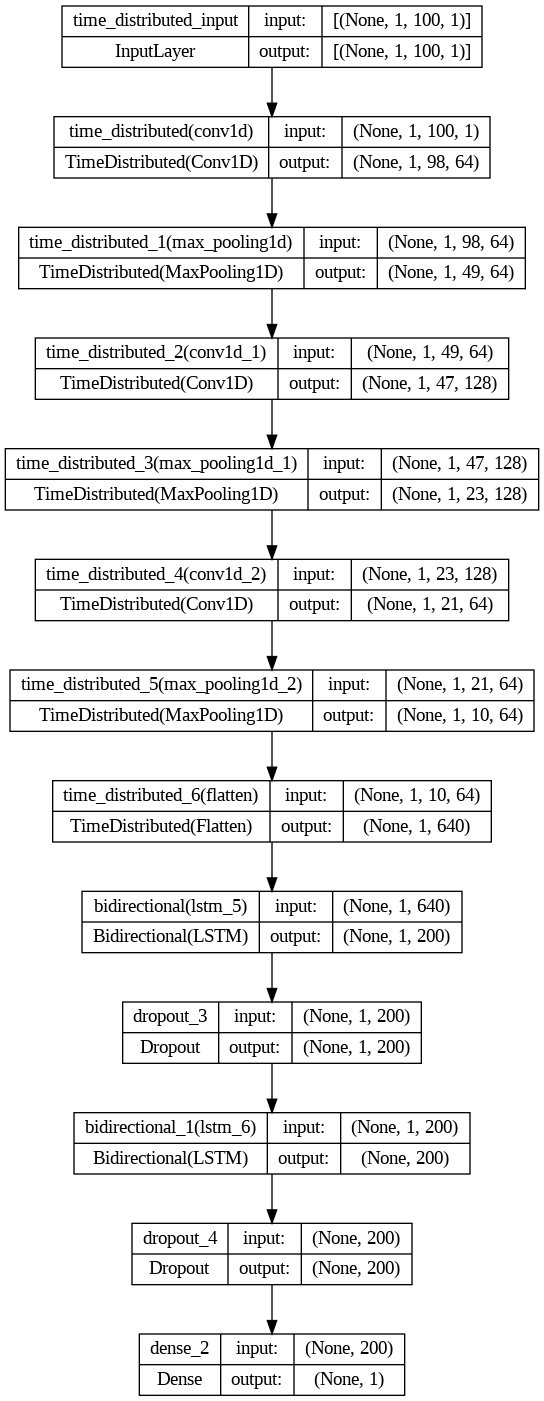

In [ ]:
# After the model has been constructed, we'll summarise it
print(model_cnn_lstm.summary())
plot_model(model_cnn_lstm, to_file='model_cnn_lstm.png', show_shapes=True, show_layer_names=True)

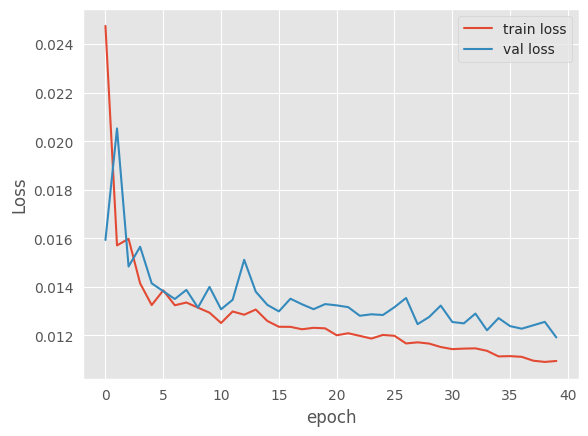

In [ ]:
#figure = fig(20, 20)
plt.plot(history_cnn_lstm.history['loss'], label='train loss')
plt.plot(history_cnn_lstm.history['val_loss'], label='val loss')
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

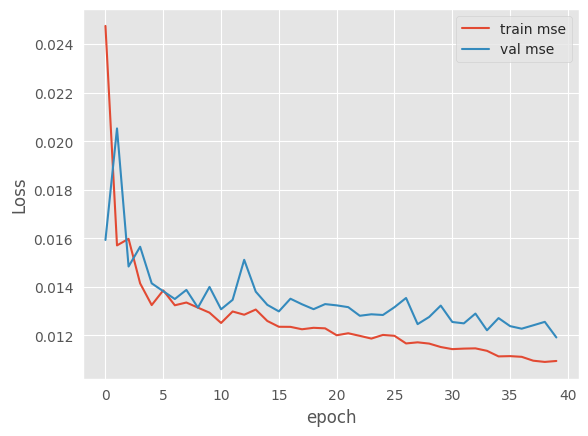

In [ ]:
plt.plot(history_cnn_lstm.history['mse'], label='train mse')
plt.plot(history_cnn_lstm.history['val_mse'], label='val mse')
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.legend()

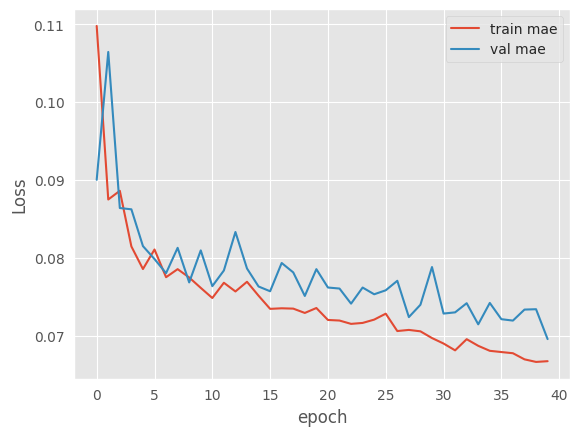

In [ ]:
plt.plot(history_cnn_lstm.history['mae'], label='train mae')
plt.plot(history_cnn_lstm.history['val_mae'], label='val mae')
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.legend()

### **Model Evaluation**

In [ ]:
result = model_cnn_lstm.evaluate(test_X, test_Y)
result

31/31 [==============================] - 0s 7ms/step - loss: 0.0119 - mse: 0.0119 - mae: 0.0696


[0.01191321574151516, 0.01191321574151516, 0.06955226510763168]

In [ ]:
print("Test Data")
print("Loss: ", result[0])
print("MSE: ", result[1])
print("RMSE: ", math.sqrt(result[1]))
print("MAE: ", result[2])

Test Data
Loss:  0.01191321574151516
MSE:  0.01191321574151516
RMSE:  0.10914767858967574
MAE:  0.06955226510763168


In [ ]:
from sklearn.metrics import explained_variance_score, mean_poisson_deviance, mean_gamma_deviance
from sklearn.metrics import r2_score
from sklearn.metrics import max_error

# predict probabilities for test set
yhat_probs = model_cnn_lstm.predict(test_X, verbose=0)

#Make a copy of it
predicted = yhat_probs.copy()

# reduce to 1d array
yhat_probs = yhat_probs[:, 0]

var = explained_variance_score(test_Y.reshape(-1,1), yhat_probs)
print('Variance: %f' % var)

r2 = r2_score(test_Y.reshape(-1,1), yhat_probs)
print('R2 Score: %f' % var)

var2 = max_error(test_Y.reshape(-1,1), yhat_probs)
print('Max Error: %f' % var2)

Variance: 0.867458
R2 Score: 0.867458
Max Error: 0.492289


In [ ]:
predicted.shape

(987, 1)

In [ ]:
yhat_probs.shape

(987,)

### **Visualizing the Predictions**

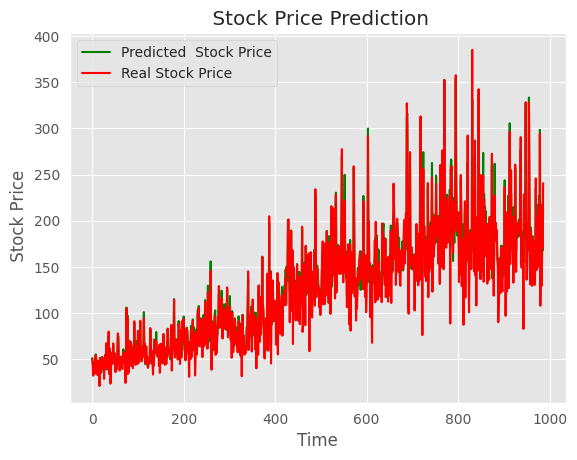

In [ ]:
test_label = test_Y.reshape(-1,1)
predicted = np.array(predicted[:,0]).reshape(-1,1)
len_t = len(train_X)
for j in range(len_t , len_t + len(test_X)):
    temp = data.iloc[j,3]
    test_label[j - len_t] = test_label[j - len_t] * temp + temp
    predicted[j - len_t] = predicted[j - len_t] * temp + temp
plt.plot(predicted, color = 'green', label = 'Predicted  Stock Price')
plt.plot(test_label, color = 'red', label = 'Real Stock Price')
plt.title(' Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel(' Stock Price')
plt.legend()
plt.show()